In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
from IPython.display import Markdown
import numpy as np
import os

import torch


MODEL_PATH= 'EP_models/'
os.environ['HF_HOME'] = MODEL_PATH  # before import transformers
os.environ['HF_DATASETS_OFFLINE']= '1'

Device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

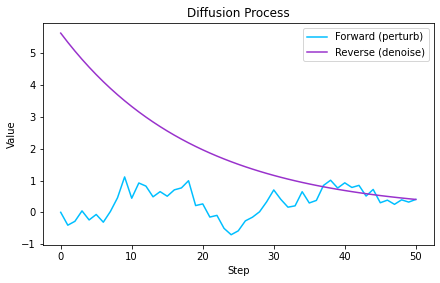

In [5]:
# run a few times

# initial data point value - original "image" in 1D
init_val = 0.0

# number of diffusion steps
T = 50

# noise parameters
alpha = 0.9  # value decay per step
beta = 1-alpha  # noise amount per step

forward_ = [init_val]

for t in range(1, T+1):
    noise = np.random.normal(0, np.sqrt(beta))
    noise_val = np.sqrt(alpha)*forward_[-1] + noise
    forward_ += [noise_val]

# Denoise - simplicity reverse/undo the value
reverse_ = [forward_[-1]]
for t in range(T,0,-1):
    denoised_val = reverse_[-1] / np.sqrt(alpha)
    reverse_ += [denoised_val]

plt.figure(figsize=(7,4), dpi=72)
plt.plot(range(T+1), forward_, label="Forward (perturb)", c="deepskyblue")
plt.plot(range(T,-1,-1), reverse_, label="Reverse (denoise)", c="darkorchid")
plt.gca().set(xlabel='Step', ylabel='Value', title='Diffusion Process')
plt.legend()
plt.show()

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

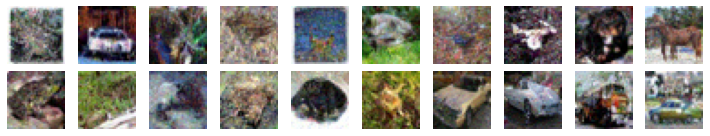

In [6]:
from diffusers import DDPMPipeline

Pipe_dif = DDPMPipeline.from_pretrained('google/ddpm-cifar10-32', cache_dir=MODEL_PATH, use_safetensors=False).to(Device)

@torch.no_grad()
def sample(n=20, steps=100, seed=0):
    g = torch.Generator(device=Device).manual_seed(seed)
    out = Pipe_dif(num_inference_steps=steps, generator=g, batch_size=n)
    return out.images  # list of PIL images (32x32)

imgs = sample(n=20, steps=100, seed=0)

fig, axes = plt.subplots(2, 10, figsize=(10, 2))
for ax, img in zip(axes.flat, imgs):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
from diffusers import StableDiffusion3Pipeline

Pipe_dif = StableDiffusion3Pipeline.from_pretrained(
    'stabilityai/stable-diffusion-3.5-medium', force_download=True, cache_dir=MODEL_PATH).to(Device)

Prompt = 'An introduction to particle swarm optimization'
Prompt_neg = 'No odd shapes'

@torch.inference_mode()
def generate_images(n=4, steps=30, seed=42):
    g = torch.Generator(device=Device).manual_seed(seed)
    out = Pipe_dif(
        prompt=[Prompt]*n,
        negative_prompt=[Prompt_neg]*n,
        num_inference_steps=steps,
        guidance_scale=4.5,
        generator=g
    )
    return out.images

# generate 4 images
images = generate_images(n=4, steps=30, seed=42)

def plot_diff(_images):
    # plot 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    for ax, img in zip(axs.flat, _images):
        ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_diff(images)

ValueError: Force download failed due to the above error.

## Gradio

In [10]:
import gradio as gr

print(f'gradio version= {gr.__version__}')

ModuleNotFoundError: No module named 'gradio'

In [ ]:
Pipe_dif = DDPMPipeline.from_pretrained('google/ddpm-celebahq-256', cache_dir=MODEL_PATH, use_safetensors=False).to(Device)

@torch.no_grad()
def sample_image(seed: int=0, steps: int=100):
    g = torch.Generator(device=Device).manual_seed(seed)
    out = Pipe_dif(generator=g, num_inference_steps=steps)
    img = out.images[0]  # PIL Image 256x256
    return img

demo = gr.Interface(
    fn=sample_image,
    inputs=[
        gr.Slider(0, 100000, value=0, step=1, label='seed'),
        gr.Slider(10, 1000, value=100, step=10, label='num_inference_steps')
    ],
    outputs=gr.Image(type='pil', label='generated 256x256 image'),
    title='DDPM CelebA-HQ 256'
)

demo.launch()

In [ ]:
%%time

@torch.no_grad()
def sample(n=10, steps=100, seed=0):
    g = torch.Generator(device=Device).manual_seed(seed)
    out = Pipe_dif(num_inference_steps=steps, generator=g, batch_size=n)
    return out.images  # list of PIL images

# generate 10 images
imgs = sample(n=10, steps=100, seed=42)

# plot as 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img in zip(axes.flat, imgs):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()